# Practical 7: Building LeNet-5 and AlexNet Architectures
## Deep Learning Lab | BTech Semester 4
## KARTIK KUMAR NDU202400012
---

### 🎯 Objective
Understand the structural evolution of CNNs by implementing two landmark architectures:
- **LeNet-5** (LeCun et al., 1998) — the first successful CNN, designed for handwritten digit recognition
- **AlexNet** (Krizhevsky et al., 2012) — won ImageNet 2012, sparked the deep learning revolution

### 📌 What You Will Learn
- How convolutional layers extract spatial features using learnable filters
- Role of pooling layers in spatial downsampling
- How architecture depth and width evolved from LeNet to AlexNet
- ReLU vs Tanh activation functions
- Structural differences: filter sizes, number of layers, number of parameters

### 📚 References
- LeCun, Y. et al. (1998) — *Gradient-Based Learning Applied to Document Recognition*
  http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf
- Krizhevsky, A. et al. (2012) — *ImageNet Classification with Deep Convolutional Neural Networks*
  https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf
- GTSRB Dataset: https://benchmark.ini.rub.de/gtsrb_news.html
- CIFAR-10: https://www.cs.toronto.edu/~kriz/cifar.html

---

## 📦 Step 1: Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow: {tf.__version__}')
print('All libraries loaded!')

TensorFlow: 2.20.0
All libraries loaded!


## 🧠 Step 2: CNN Fundamentals — Convolution Operation

Before building the architectures, let's understand what a convolution does visually.

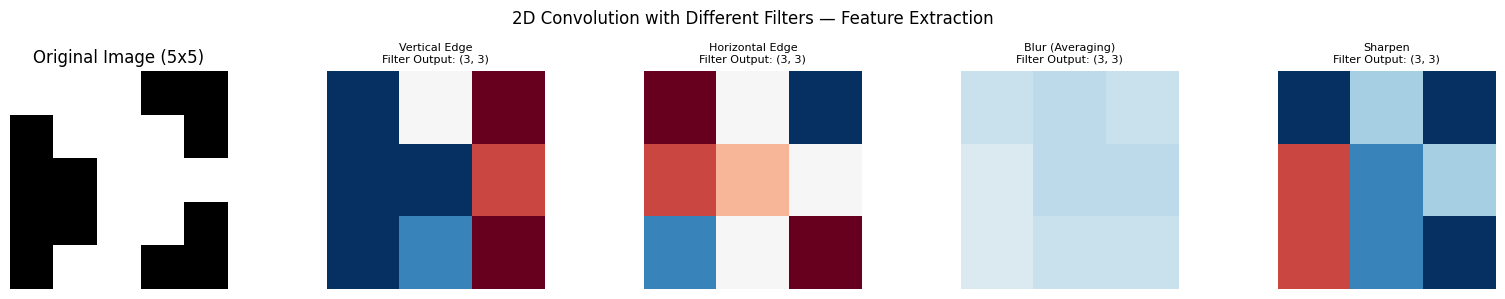

Key Insight: Different filters detect different features.
In CNN training, the filter values are LEARNED automatically via backpropagation!


In [2]:
# manually doing 2D convolution to understand what's actually happening inside a conv layer
# a filter slides across the image and computes dot products at each position

# creating a small 5x5 test image
image = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
], dtype=float)

# different filters detect different features — edges, blur, sharpening etc.
filters = {
    'Vertical Edge': np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    'Horizontal Edge': np.array([[-1,-2,-1], [0, 0, 0], [1, 2, 1]]),
    'Blur (Averaging)': np.ones((3,3)) / 9,
    'Sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
}

# applying the filter by sliding it across the image manually
def convolve2d(img, kernel):
    """sliding the filter kernel across the image and computing dot product at each position"""
    h, w = img.shape
    kh, kw = kernel.shape
    out_h = h - kh + 1
    out_w = w - kw + 1
    output = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            output[i, j] = np.sum(img[i:i+kh, j:j+kw] * kernel)
    return output

# showing the original image and what each filter produces
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original Image (5x5)')
axes[0].axis('off')

for ax, (name, filt) in zip(axes[1:], filters.items()):
    result = convolve2d(image, filt)
    ax.imshow(result, cmap='RdBu', vmin=-3, vmax=3)
    ax.set_title(f'{name}\nFilter Output: {result.shape}', fontsize=8)
    ax.axis('off')

plt.suptitle('2D Convolution with Different Filters — Feature Extraction', fontsize=12)
plt.tight_layout()
plt.show()

print('different filters respond to different patterns in the image')
print('in CNN training the filter values are NOT manually set — backprop learns them automatically!')

## 📊 Step 3: Load Datasets

- **LeNet-5** → MNIST (28×28 grayscale) — resize to 32×32 (original LeNet input size)
- **AlexNet** → CIFAR-10 (32×32 RGB) — upscale to 64×64 for AlexNet-style processing

In [3]:
# loading MNIST for LeNet-5
(X_mnist_train, y_mnist_train), (X_mnist_test, y_mnist_test) = keras.datasets.mnist.load_data()

# LeNet-5 was designed for 32x32 inputs, so we resize from the original 28x28
# also normalizing and adding a channel dimension since Conv2D needs (H, W, C) format
X_mnist_train = np.expand_dims(X_mnist_train.astype('float32') / 255.0, -1)  # (60000, 28, 28, 1)
X_mnist_test  = np.expand_dims(X_mnist_test.astype('float32')  / 255.0, -1)

# using TensorFlow's resize to get from 28x28 to 32x32
X_mnist_train = tf.image.resize(X_mnist_train, [32, 32]).numpy()
X_mnist_test  = tf.image.resize(X_mnist_test,  [32, 32]).numpy()

print(f'MNIST (for LeNet-5): Train {X_mnist_train.shape}, Test {X_mnist_test.shape}')

# loading CIFAR-10 for AlexNet
(X_cifar_train, y_cifar_train), (X_cifar_test, y_cifar_test) = keras.datasets.cifar10.load_data()

X_cifar_train = X_cifar_train.astype('float32') / 255.0
X_cifar_test  = X_cifar_test.astype('float32')  / 255.0

# upscaling to 64x64 because AlexNet's architecture needs more spatial resolution
X_cifar_train = tf.image.resize(X_cifar_train, [64, 64]).numpy()
X_cifar_test  = tf.image.resize(X_cifar_test,  [64, 64]).numpy()

cifar_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
print(f'CIFAR-10 (for AlexNet): Train {X_cifar_train.shape}, Test {X_cifar_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST (for LeNet-5): Train (60000, 32, 32, 1), Test (10000, 32, 32, 1)
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 186s 1us/step
CIFAR-10 (for AlexNet): Train (50000, 64, 64, 3), Test (10000, 64, 64, 3)


## 🏗️ Step 4: Implement LeNet-5

### Architecture (LeCun 1998):
```
Input (32x32x1)
  → Conv2D(6 filters, 5x5, tanh)  → AvgPool(2x2)    [C1, S2]
  → Conv2D(16 filters, 5x5, tanh) → AvgPool(2x2)    [C3, S4]
  → Conv2D(120 filters, 5x5, tanh)                   [C5]
  → Flatten
  → Dense(84, tanh)                                   [F6]
  → Dense(10, softmax)                                [Output]
```

**Design Philosophy:** Small filters (5×5), average pooling, tanh activations. Only 60K parameters!

In [4]:
def build_lenet5(input_shape=(32, 32, 1), num_classes=10):
    """
    LeNet-5 as described in LeCun et al. (1998).

    Original used average pooling and tanh; we keep the original design.
    Total parameters: ~60,000 — tiny by modern standards!
    """
    model = keras.Sequential([
        # ---- convolutional feature extraction section ----
        # C1: first conv layer — 6 filters of size 5x5, output becomes 28x28x6
        layers.Conv2D(6, kernel_size=5, activation='tanh',
                      padding='valid', input_shape=input_shape, name='C1_conv'),

        # S2: average pooling to downsample, output becomes 14x14x6
        layers.AveragePooling2D(pool_size=2, strides=2, name='S2_avgpool'),

        # C3: second conv layer — 16 filters of 5x5, output becomes 10x10x16
        layers.Conv2D(16, kernel_size=5, activation='tanh',
                      padding='valid', name='C3_conv'),

        # S4: another pooling layer, output becomes 5x5x16
        layers.AveragePooling2D(pool_size=2, strides=2, name='S4_avgpool'),

        # C5: final conv layer — 120 filters, 5x5 — output shrinks to 1x1x120 (acts like a fully connected layer)
        layers.Conv2D(120, kernel_size=5, activation='tanh',
                      padding='valid', name='C5_conv'),

        # ---- fully connected classification section ----
        layers.Flatten(name='flatten'),

        # F6: 84 neurons — LeCun chose this number intentionally, related to ASCII character encoding
        layers.Dense(84, activation='tanh', name='F6_dense'),

        # Output: 10 classes
        layers.Dense(num_classes, activation='softmax', name='Output')
    ], name='LeNet-5')

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model


lenet = build_lenet5()
lenet.summary()
print(f'\nTotal parameters: {lenet.count_params():,}')

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1_conv (Conv2D)                │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S2_avgpool (AveragePooling2D)   │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3_conv (Conv2D)                │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ S4_avgpool (AveragePooling2D)   │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C5_conv (Conv2D)                │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ F6_dense (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 61,706


## 📈 Step 5: Visualize LeNet-5 Architecture

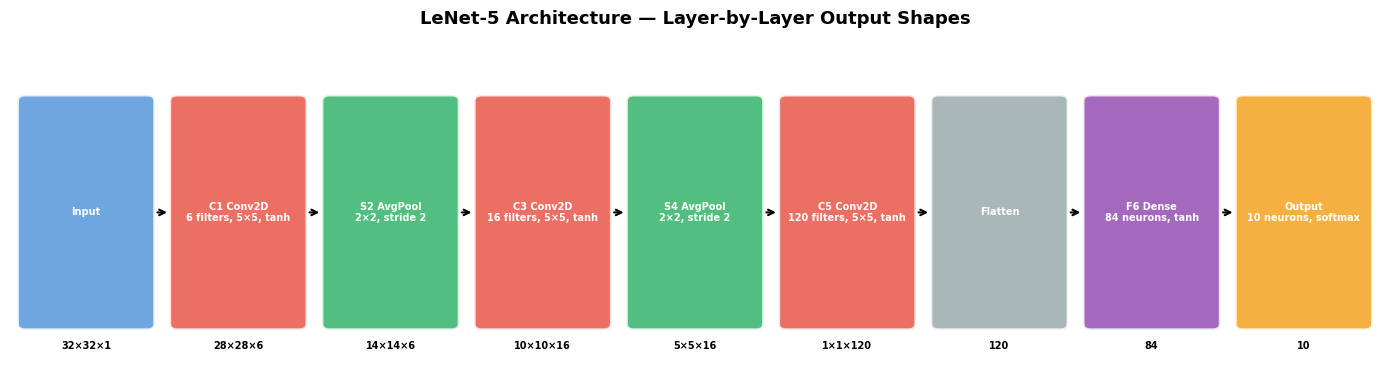

In [5]:
# showing the original image and what each filter produces the layer-by-layer output shapes as a diagram
lenet_layers = [
    ('Input',       '32×32×1',   '#4A90D9'),
    ('C1 Conv2D\n6 filters, 5×5, tanh',  '28×28×6',  '#E74C3C'),
    ('S2 AvgPool\n2×2, stride 2',         '14×14×6',  '#27AE60'),
    ('C3 Conv2D\n16 filters, 5×5, tanh', '10×10×16', '#E74C3C'),
    ('S4 AvgPool\n2×2, stride 2',         '5×5×16',   '#27AE60'),
    ('C5 Conv2D\n120 filters, 5×5, tanh','1×1×120',  '#E74C3C'),
    ('Flatten',     '120',        '#95A5A6'),
    ('F6 Dense\n84 neurons, tanh',        '84',        '#8E44AD'),
    ('Output\n10 neurons, softmax',       '10',        '#F39C12'),
]

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, len(lenet_layers))
ax.set_ylim(0, 3)
ax.axis('off')

for i, (name, shape, color) in enumerate(lenet_layers):
    rect = mpatches.FancyBboxPatch((i + 0.1, 0.5), 0.8, 2,
                                    boxstyle='round,pad=0.05',
                                    facecolor=color, alpha=0.8, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(i + 0.5, 1.5, name, ha='center', va='center', fontsize=7,
            color='white', fontweight='bold', wrap=True)
    ax.text(i + 0.5, 0.3, shape, ha='center', va='center', fontsize=7,
            color='black', fontweight='bold')
    if i < len(lenet_layers) - 1:
        ax.annotate('', xy=(i + 1.05, 1.5), xytext=(i + 0.95, 1.5),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

plt.title('LeNet-5 Architecture — Layer-by-Layer Output Shapes', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 🚀 Step 6: Train LeNet-5 on MNIST

In [6]:
print('training LeNet-5 on MNIST...')
lenet_history = lenet.fit(
    X_mnist_train, y_mnist_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

lenet_test_loss, lenet_test_acc = lenet.evaluate(X_mnist_test, y_mnist_test, verbose=0)
print(f'\nLeNet-5 Test Accuracy: {lenet_test_acc*100:.2f}%')

Training LeNet-5 on MNIST (32x32x1)...
Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.9202 - loss: 0.2708 - val_accuracy: 0.9698 - val_loss: 0.0988
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9707 - loss: 0.0976 - val_accuracy: 0.9805 - val_loss: 0.0686
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9802 - loss: 0.0638 - val_accuracy: 0.9847 - val_loss: 0.0589
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 36ms/step - accuracy: 0.9866 - loss: 0.0458 - val_accuracy: 0.9843 - val_loss: 0.0603
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.9901 - loss: 0.0336 - val_accuracy: 0.9838 - val_loss: 0.0591
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9928 - loss: 0.0252 - val_accuracy: 0.9853 - val_loss: 0.0581
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.9941 - loss: 0.0202 - val_accuracy: 0.9847 - val_loss: 0.0574
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/st

## 🏗️ Step 7: Implement AlexNet (Scaled-Down)

### Architecture (Krizhevsky 2012 — adapted for CIFAR-10):
```
Input (64x64x3)
  → Conv2D(96, 11x11, stride 4, ReLU) → MaxPool(3x3, stride 2)   [Block 1]
  → Conv2D(256, 5x5, same, ReLU)      → MaxPool(3x3, stride 2)   [Block 2]
  → Conv2D(384, 3x3, same, ReLU)                                   [Block 3]
  → Conv2D(384, 3x3, same, ReLU)                                   [Block 4]
  → Conv2D(256, 3x3, same, ReLU)      → MaxPool(3x3, stride 2)   [Block 5]
  → Flatten → Dense(4096, ReLU) → Dropout(0.5)
  → Dense(4096, ReLU) → Dropout(0.5)
  → Dense(10, softmax)
```

**Key innovations over LeNet:**
- ReLU instead of tanh → faster training, no vanishing gradients
- Max Pooling instead of Average Pooling → stronger feature selection
- Dropout → prevents overfitting
- Much deeper: 5 conv layers + 3 FC layers vs LeNet's 3+2

In [7]:
def build_alexnet_mini(input_shape=(64, 64, 3), num_classes=10):
    """
    Scaled-down AlexNet adapted for CIFAR-10 at 64x64.
    Original AlexNet used 227x227 and 1000 classes (ImageNet).

    Key innovations introduced by AlexNet (2012):
    1. ReLU activations (faster, no vanishing gradient)
    2. Max pooling (instead of average pooling)
    3. Dropout regularization
    4. Data augmentation (not shown here)
    5. Multi-GPU training (not applicable here)
    """
    model = keras.Sequential([
        # Block 1: large filter (5x5) to capture big coarse features first
        # original AlexNet used 11x11 filters — we scaled down for CIFAR-10
        layers.Conv2D(96, kernel_size=5, strides=2, activation='relu',
                      padding='same', input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='pool1'),
        layers.BatchNormalization(name='bn1'),  # original used LRN (Local Response Normalization), BN works better

        # Block 2: extracting medium-scale features
        layers.Conv2D(256, kernel_size=5, activation='relu',
                      padding='same', name='conv2'),
        layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='pool2'),
        layers.BatchNormalization(name='bn2'),

        # Block 3: three conv layers in a row to extract fine-grained features (no pooling here)
        layers.Conv2D(384, kernel_size=3, activation='relu',
                      padding='same', name='conv3'),
        layers.Conv2D(384, kernel_size=3, activation='relu',
                      padding='same', name='conv4'),
        layers.Conv2D(256, kernel_size=3, activation='relu',
                      padding='same', name='conv5'),
        layers.MaxPooling2D(pool_size=3, strides=2, padding='same', name='pool3'),

        # fully connected layers for final classification
        layers.Flatten(name='flatten'),
        layers.Dense(2048, activation='relu', name='fc6'),  # Original: 4096
        layers.Dropout(0.5, name='drop6'),                  # dropping 50% of neurons to prevent overfitting
        layers.Dense(2048, activation='relu', name='fc7'),
        layers.Dropout(0.5, name='drop7'),
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name='AlexNet-Mini')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


alexnet = build_alexnet_mini()
alexnet.summary()
print(f'\nTotal parameters: {alexnet.count_params():,}')
print(f'LeNet-5 params: {lenet.count_params():,}')
print(f'AlexNet params: {alexnet.count_params():,} ({alexnet.count_params()/lenet.count_params():.0f}x more than LeNet-5)')

Model: "AlexNet-Mini"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 32, 32, 96)     │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 16, 16, 96)     │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 16, 16, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 8, 8, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc6 (Dense)                     │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop6 (Dropout)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc7 (Dense)                     │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop7 (Dropout)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,328,458 (62.29 MB)

 Trainable params: 16,327,754 (62.29 MB)

 Non-trainable params: 704 (2.75 KB)


Total parameters: 16,328,458
LeNet-5 params: 61,706
AlexNet params: 16,328,458 (265x more than LeNet-5)


## 📈 Step 8: Visualize AlexNet Architecture

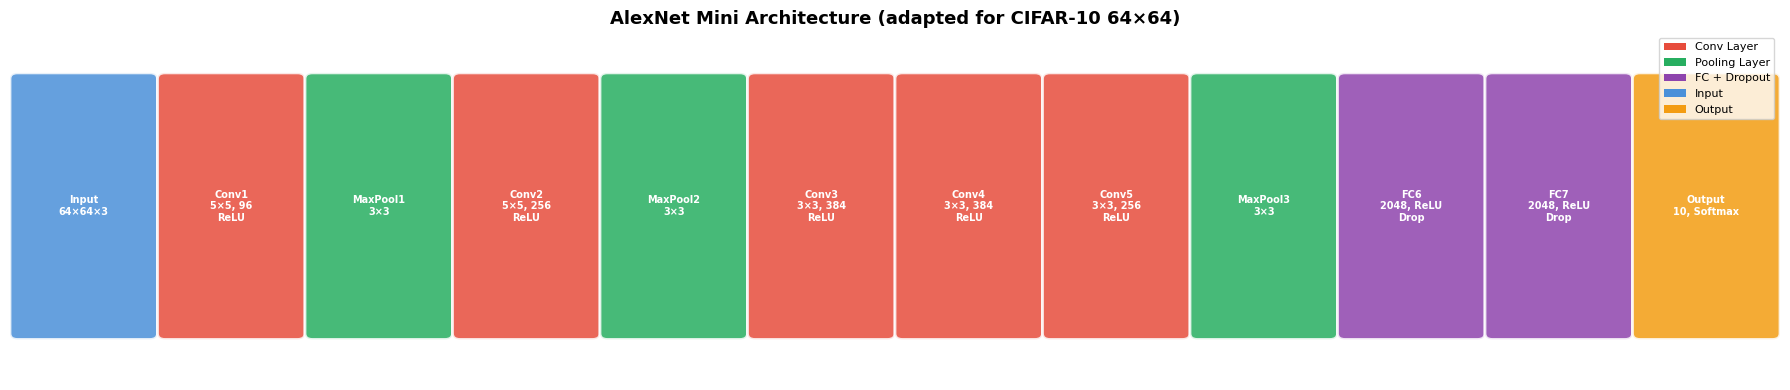

In [8]:
alexnet_layers = [
    ('Input\n64×64×3',       '#4A90D9'),
    ('Conv1\n5×5, 96\nReLU',  '#E74C3C'),
    ('MaxPool1\n3×3',         '#27AE60'),
    ('Conv2\n5×5, 256\nReLU', '#E74C3C'),
    ('MaxPool2\n3×3',         '#27AE60'),
    ('Conv3\n3×3, 384\nReLU', '#E74C3C'),
    ('Conv4\n3×3, 384\nReLU', '#E74C3C'),
    ('Conv5\n3×3, 256\nReLU', '#E74C3C'),
    ('MaxPool3\n3×3',         '#27AE60'),
    ('FC6\n2048, ReLU\nDrop', '#8E44AD'),
    ('FC7\n2048, ReLU\nDrop', '#8E44AD'),
    ('Output\n10, Softmax',   '#F39C12'),
]

fig, ax = plt.subplots(figsize=(18, 4))
ax.set_xlim(0, len(alexnet_layers))
ax.set_ylim(0, 3)
ax.axis('off')

for i, (name, color) in enumerate(alexnet_layers):
    rect = mpatches.FancyBboxPatch((i+0.05, 0.4), 0.9, 2.2,
                                    boxstyle='round,pad=0.05',
                                    facecolor=color, alpha=0.85, edgecolor='white', linewidth=2)
    ax.add_patch(rect)
    ax.text(i+0.5, 1.5, name, ha='center', va='center', fontsize=7,
            color='white', fontweight='bold')
    if i < len(alexnet_layers) - 1:
        ax.annotate('', xy=(i+1.0, 1.5), xytext=(i+1.0, 1.5),
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

legend_elements = [
    mpatches.Patch(facecolor='#E74C3C', label='Conv Layer'),
    mpatches.Patch(facecolor='#27AE60', label='Pooling Layer'),
    mpatches.Patch(facecolor='#8E44AD', label='FC + Dropout'),
    mpatches.Patch(facecolor='#4A90D9', label='Input'),
    mpatches.Patch(facecolor='#F39C12', label='Output'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
plt.title('AlexNet Mini Architecture (adapted for CIFAR-10 64×64)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🚀 Step 9: Train AlexNet on CIFAR-10

In [ ]:
# data augmentation: randomly flipping/rotating/zooming images to artificially increase dataset size
# AlexNet was one of the first to heavily use this technique
data_aug = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name='DataAugmentation')

print('Training AlexNet-Mini on CIFAR-10 (64x64x3)...')
print('(This may take several minutes on CPU — consider enabling GPU in Colab)')

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8, restore_best_weights=True
)

alexnet_history = alexnet.fit(
    X_cifar_train, y_cifar_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

alexnet_test_loss, alexnet_test_acc = alexnet.evaluate(X_cifar_test, y_cifar_test, verbose=0)
print(f'\nAlexNet-Mini Test Accuracy: {alexnet_test_acc*100:.2f}%')

## 📊 Step 10: Compare Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LeNet-5 curves
h1 = lenet_history.history
axes[0].plot(h1['accuracy'], 'b-', label='Train', linewidth=2)
axes[0].plot(h1['val_accuracy'], 'b--', label='Validation', linewidth=2)
axes[0].set_title(f'LeNet-5 on MNIST\nTest Acc: {lenet_test_acc*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AlexNet curves
h2 = alexnet_history.history
axes[1].plot(h2['accuracy'], 'r-', label='Train', linewidth=2)
axes[1].plot(h2['val_accuracy'], 'r--', label='Validation', linewidth=2)
axes[1].set_title(f'AlexNet-Mini on CIFAR-10\nTest Acc: {alexnet_test_acc*100:.2f}%', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LeNet-5 vs AlexNet-Mini: Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔍 Step 11: Visualize Learned Feature Maps

In [ ]:
# showing the original image and what each filter produces what the first conv layer of LeNet-5 has learned
# Extract feature maps (activations) for a sample MNIST image

# building a mini model that gives us the output of the first conv layer — so we can see what it learned
feature_extractor = keras.Model(
    inputs=lenet.input,
    outputs=lenet.get_layer('C1_conv').output
)

# Take one test image
sample = X_mnist_test[0:1]  # picking one test image to visualize
feature_maps = feature_extractor.predict(sample, verbose=0)  # running it through to get the 6 feature maps

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

# showing the input image in the first subplot
axes[0, 0].imshow(sample[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Input Image', fontsize=10, fontweight='bold')
axes[0, 0].axis('off')

# showing what each of the 6 learned filters responds to
for i in range(6):
    row, col = divmod(i + 1, 4)
    axes[row, col].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[row, col].set_title(f'Filter {i+1} Output', fontsize=9)
    axes[row, col].axis('off')

# hiding the empty subplot we don't need
axes[1, 3].axis('off')

plt.suptitle('LeNet-5: Feature Maps After C1 Conv Layer (Learned Filters)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('each feature map lights up for a different pattern — edges, curves, corners etc.')

## 📋 Step 12: Architecture Comparison Table

In [ ]:
comparison = pd.DataFrame({
    'Property': ['Year', 'Input Size', 'Conv Layers', 'FC Layers', 'Activation',
                 'Pooling Type', 'Dropout', 'Total Parameters', 'Dataset', 'Test Accuracy'],
    'LeNet-5': ['1998', '32×32×1', '3 (C1,C3,C5)', '2 (F6+Out)', 'Tanh',
                'Average', 'No', f'{lenet.count_params():,}',
                'MNIST (digits)', f'{lenet_test_acc*100:.2f}%'],
    'AlexNet-Mini': ['2012 (adapted)', '64×64×3', '5 (conv1-5)', '3 (fc6,fc7+Out)', 'ReLU',
                     'Max', 'Yes (0.5)', f'{alexnet.count_params():,}',
                     'CIFAR-10 (objects)', f'{alexnet_test_acc*100:.2f}%']
})

print('Architecture Comparison:')
print(comparison.to_string(index=False))

---

## 📝 Summary

| Feature | LeNet-5 | AlexNet |
|---------|---------|--------|
| Year | 1998 | 2012 |
| Activation | Tanh | ReLU (faster, avoids vanishing gradient) |
| Pooling | Average | Max (stronger feature selection) |
| Regularization | None | Dropout |
| Parameters | ~60K | Millions |
| Task | Digit recognition | Object classification |
| Significance | First practical CNN | Ignited the deep learning revolution |

---

## ❓ Viva / Self-Check Questions

1. **What is a convolutional layer?** How does it differ from a fully connected (Dense) layer? What is weight sharing?

2. **What is a filter/kernel in a CNN?** How are filter values determined during training?

3. **What is the difference between Valid padding and Same padding?** How does each affect output dimensions?

4. **Why did AlexNet use ReLU instead of Tanh/Sigmoid?** What is the vanishing gradient problem in the context of Tanh?

5. **What is Max Pooling?** Why does it outperform Average Pooling for classification tasks?

6. **Why does the number of parameters in the fully connected layers dwarf those in convolutional layers?**

7. **What are feature maps?** What does each feature map represent after a convolutional layer?

8. **Given an input of 28×28 with a 5×5 filter, stride=1, no padding — what is the output size? Show the formula.**